# 0.2 Descarga red peatonal (OSMnx)

Versión paramétrica de `download_pedestrian_network.ipynb` (que usaba un bounding
box WKT fijo de Peñalolén). Ahora la red se descarga con el polígono AOI exacto
de la zona activa, con un buffer de 300 m para que las rutas cerca del borde
no queden cortadas artificialmente.

**Entrada:** `data/raw/aoi_{zona}.gpkg` (nb 0)

**Salida:** `data/raw/red_peatonal_{zona}.graphml`

**Nota de escala:** para `gran_santiago` la descarga puede tardar >30 min y el
grafo puede superar el millón de nodos. Overpass puede aplicar rate-limiting;
si falla, reintentar (OSMnx cachea las respuestas parciales en `./cache`).

---

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from config import ZONA, FP_AOI, FP_RED, CRS_GEO, CRS_PROJ

import geopandas as gpd
import osmnx as ox

ox.settings.log_console = True
print(f'Zona: {ZONA} | salida: {FP_RED.name}')

Zona: suroriente | salida: red_peatonal_suroriente.graphml


## 1. AOI + buffer de borde

In [2]:
BUFFER_M = 300  # margen para no cortar rutas en el borde de la zona

aoi = gpd.read_file(FP_AOI, layer='aoi')
aoi_buf = (aoi.to_crs(CRS_PROJ).buffer(BUFFER_M)).to_crs(CRS_GEO)
polygon = aoi_buf.iloc[0]

area_km2 = aoi.to_crs(CRS_PROJ).geometry.area.iloc[0] / 1e6
print(f'AOI: {area_km2:,.1f} km² (+{BUFFER_M} m de buffer)')

AOI: 177.6 km² (+300 m de buffer)


## 2. Descarga de la red walk

In [3]:
%%time
G = ox.graph_from_polygon(polygon, network_type='walk', simplify=True)
print(f'Nodos: {len(G.nodes):,} | Aristas: {len(G.edges):,}')

Nodos: 48,462 | Aristas: 144,766
CPU times: total: 28.5 s
Wall time: 1min 2s


## 3. Guardar y verificar

Guardado: C:\Users\mbell\Desktop\UNIVERSIDAD\DOCTORADO\TESIS\REPOSITORIOS\simulador-am-tesis\data\raw\red_peatonal_suroriente.graphml (59.8 MB)


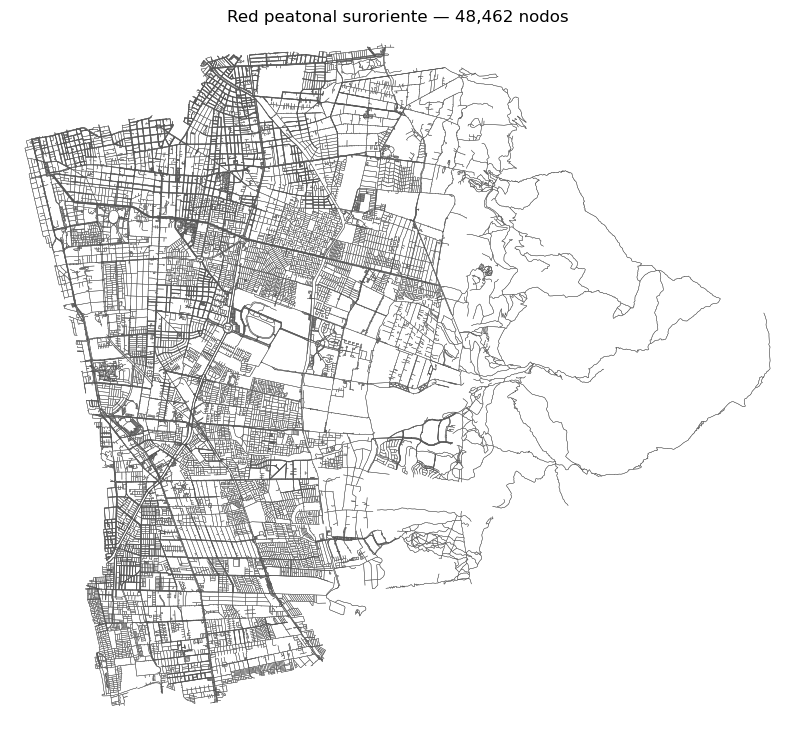

In [4]:
ox.save_graphml(G, filepath=str(FP_RED))
size_mb = FP_RED.stat().st_size / 1e6
print(f'Guardado: {FP_RED} ({size_mb:,.1f} MB)')

# Vista rápida (para zonas grandes esto puede ser lento — opcional)
if len(G.nodes) < 300_000:
    fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.3,
                            edge_color='#555', bgcolor='white',
                            figsize=(10, 10), show=False, close=False)
    ax.set_title(f'Red peatonal {ZONA} — {len(G.nodes):,} nodos')
else:
    print('Grafo grande — se omite el plot (usar QGIS si se necesita inspección visual)')